# 12-LangSmith Observability & Tracing

In Lesson 11, we engineered Resilient Error Handling. We wrapped our physical tools in topological `try/except` boundaries, allowing our agent to intercept Python crashes, read the tracebacks, and self-correct dynamically.

However, as we push into production Enterprise architectures, a new physical limitation emerges: **The Unobservable Black Box**.
If a 15-agent Hierarchical Swarm takes 45 seconds to answer a user prompt, and the final answer is slightly wrong, how do you debug it?

* Did the Supervisor route to the wrong agent?
* Did the Vector DB retrieve bad context?
* Did the LLM hallucinate the tool parameters?
* Did the Python tool execute correctly but return an unparsed string?

In classical Control Theory, a system is only safe if it is **Observable**. We must integrate distributed telemetry into our graph. We must inject a tracing engine that records every single tensor activation, token generation, and state mutation in real-time.

Furthermore, hardcoding API keys into a Python script is a catastrophic security vulnerability. We will architect this system strictly using `python-dotenv` to inject our telemetry credentials via a secure mathematical environment boundary.

Let's set up our environment.

In [2]:
# Required installations: pip install langchain langchain-core langchain-ollama langgraph python-dotenv matplotlib seaborn
import os
import time
from typing import TypedDict, Annotated
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, ToolMessage
from langchain_core.tools import tool
from langchain_ollama import ChatOllama
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.graph.message import add_messages
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Systems Architecture & Secure Telemetry Environment Ready.")

✅ Systems Architecture & Secure Telemetry Environment Ready.


# 1. The Mathematics of State Observability

In Control Theory, the **Observability Matrix** determines if the internal states $x_t$ of a dynamic system can be inferred by simply observing its external outputs $y_t$.

For a Multi-Agent LLM pipeline, the standard output is just a single string:


$$y_{final} = \text{"The total cost is \$450."}$$

Mathematically, this system is **Unobservable** from the outside. You cannot look at $y_{final}$ and reconstruct the intermediate reasoning steps ($h_1, h_2, \dots, h_n$) that produced it.

To solve this, LangSmith injects a **Trace Tree** into the execution context.
Let $\mathcal{T}$ be a Trace. A Trace is a Directed Rooted Tree composed of Spans $S$.


$$S = (id, \text{parent\_id}, \text{start\_time}, \text{end\_time}, \text{inputs}, \text{outputs}, \text{metadata})$$

Every time a LangGraph Node, LLM Invoke, or Tool Execution occurs, the framework spawns a child Span $S_{child}$, records the exact inputs, measures the latency $\Delta t$, captures the outputs, and streams this telemetry asynchronously to the LangSmith backend.

# 2. Architecting the Secure Telemetry Engine

To securely stream this data, we define an environmental boundary file (`.env`). This file physically sits outside our Python execution script and is never committed to Git.

**Create a file named `.env` in your root directory containing exactly this:**

```text
LANGCHAIN_TRACING_V2=true
LANGCHAIN_ENDPOINT="https://api.smith.langchain.com"
LANGCHAIN_API_KEY="ls__YOUR_ACTUAL_LANGSMITH_API_KEY_HERE"
LANGCHAIN_PROJECT="Enterprise_Agent_Telemetry"

```

Now, let's instrument a real LangGraph application. Because LangChain is natively pre-instrumented, we only need to invoke `load_dotenv()` to activate the physics of the tracing engine.

In [3]:
# --- 📡 The Secure Telemetry Activation Engine ---

# 1. Inject the Physics Constants securely from the .env file
# This completely decouples our secrets from our source code.
env_loaded = load_dotenv()
if not env_loaded or "LANGCHAIN_API_KEY" not in os.environ:
    print("⚠️ WARNING: .env file or LANGCHAIN_API_KEY not found. Traces will be printed locally but not sent to the cloud.")
else:
    print("✅ Secure Telemetry Configuration Loaded via dotenv.")

# 2. Define the State
class AgentState(TypedDict):
    messages: Annotated[list, add_messages]

# 3. Define a Physical Tool with simulated compute latency
@tool
def calculate_compound_interest(principal: float, rate: float, years: int) -> float:
    """Calculates compound interest assuming annual compounding."""
    print(f"   ⚙️ [TOOL EXECUTION] Calculating {principal} at {rate}% for {years} years...")
    time.sleep(0.5) # Simulating GPU/Database latency for the Trace visualization
    return round(principal * ((1 + rate) ** years), 2)

# 4. Initialize Local Model and Bind Tools
# Because `load_dotenv()` was executed, LangChain automatically attaches 
# a background tracing callback to this specific ChatOllama object.
llm = ChatOllama(model="llama3.2", temperature=0)
llm_with_tools = llm.bind_tools([calculate_compound_interest])

# 5. Define Nodes
def agent_node(state: AgentState):
    print("   🧠 [NODE: Policy Network] Generating Action...")
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

def tool_node(state: AgentState):
    print("   🛠️ [NODE: Executor] Running requested tools...")
    last_msg = state["messages"][-1]
    responses = []
    for tc in last_msg.tool_calls:
        if tc["name"] == "calculate_compound_interest":
            res = calculate_compound_interest.invoke(tc["args"])
            # Defensive fix: using .get() to prevent KeyError if local model omits tool call id
            tool_id = tc.get("id", "default_tool_id")
            responses.append(ToolMessage(content=str(res), tool_call_id=tool_id))
    
    # Defensive fix: Gives Ollama a brief moment to stabilize VRAM usage between graph steps
    time.sleep(1)
    return {"messages": responses}

def router(state: AgentState):
    last_msg = state["messages"][-1]
    if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
        return "Tools"
    return END

# 6. Compile the Graph
print("--- 🏗️ Compiling Traceable StateGraph ---")
workflow = StateGraph(AgentState)
workflow.add_node("Agent", agent_node)
workflow.add_node("Tools", tool_node)
workflow.add_edge(START, "Agent")
workflow.add_conditional_edges("Agent", router, {"Tools": "Tools", END: END})
workflow.add_edge("Tools", "Agent")
app = workflow.compile()

# 7. Execute the Physics (Streaming Telemetry to Cloud)
print("\n--- 🚀 Initiating Telemetry-Tracked Execution ---")
S_0 = {"messages": [HumanMessage(content="If I invest $25,000 at a 6% interest rate for 5 years, what is my final amount?")]}

# We inject physical 'tags' and 'metadata' into the trace dynamically at execution time
execution_config = {
    "tags": ["v1.0-llama3.2-local", "financial-module", "dotenv-secured"],
    "metadata": {"user_tier": "enterprise", "session_id": "xyz-994"}
}

# When this runs, LangSmith records the entire multi-hop tree silently in the background
final_state = app.invoke(S_0, config=execution_config)

print("\n--- 🏁 Final Output ---")
print(final_state["messages"][-1].content)

print("\n--- 💡 Engineering Insight ---")
print("We have completely isolated our API secrets from the execution layer using `python-dotenv`. If you look at your LangSmith dashboard, a massive JSON payload was just asynchronously streamed to the cloud. It recorded the exact prompt fed to Llama 3.2, the token-generation latency, the JSON tool arguments coerced by the LLM, the 0.5s execution time of our Python function, and the final synthesized response.")

✅ Secure Telemetry Configuration Loaded via dotenv.
--- 🏗️ Compiling Traceable StateGraph ---

--- 🚀 Initiating Telemetry-Tracked Execution ---
   🧠 [NODE: Policy Network] Generating Action...
   🛠️ [NODE: Executor] Running requested tools...
   ⚙️ [TOOL EXECUTION] Calculating 25000.0 at 0.06% for 5 years...
   🧠 [NODE: Policy Network] Generating Action...

--- 🏁 Final Output ---
The final amount of your investment after 5 years at a 6% interest rate is approximately $33,455.64.

--- 💡 Engineering Insight ---
We have completely isolated our API secrets from the execution layer using `python-dotenv`. If you look at your LangSmith dashboard, a massive JSON payload was just asynchronously streamed to the cloud. It recorded the exact prompt fed to Llama 3.2, the token-generation latency, the JSON tool arguments coerced by the LLM, the 0.5s execution time of our Python function, and the final synthesized response.


# 3. Visualizing the Distributed Trace Tree (Flame Graph)

To understand exactly what LangSmith calculates in the cloud, we must visualize the **Call Stack Geometry** (often referred to as a Flame Graph or Trace Tree).

This visualization proves how parent Spans geometrically encompass the temporal execution of their child Spans.

/tmp/ipykernel_81528/2919677801.py:21: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = patches.Rectangle((start, y - 0.3), duration, 0.6, fill=True, color=color, alpha=0.9, edgecolor='black', linewidth=1)
/tmp/ipykernel_81528/2919677801.py:52: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  metadata_box = patches.FancyBboxPatch((3.5, 7.5), 1.2, 1.6, boxstyle="round,pad=0.1", fill=True, color='white', edgecolor='black', linewidth=1.5)


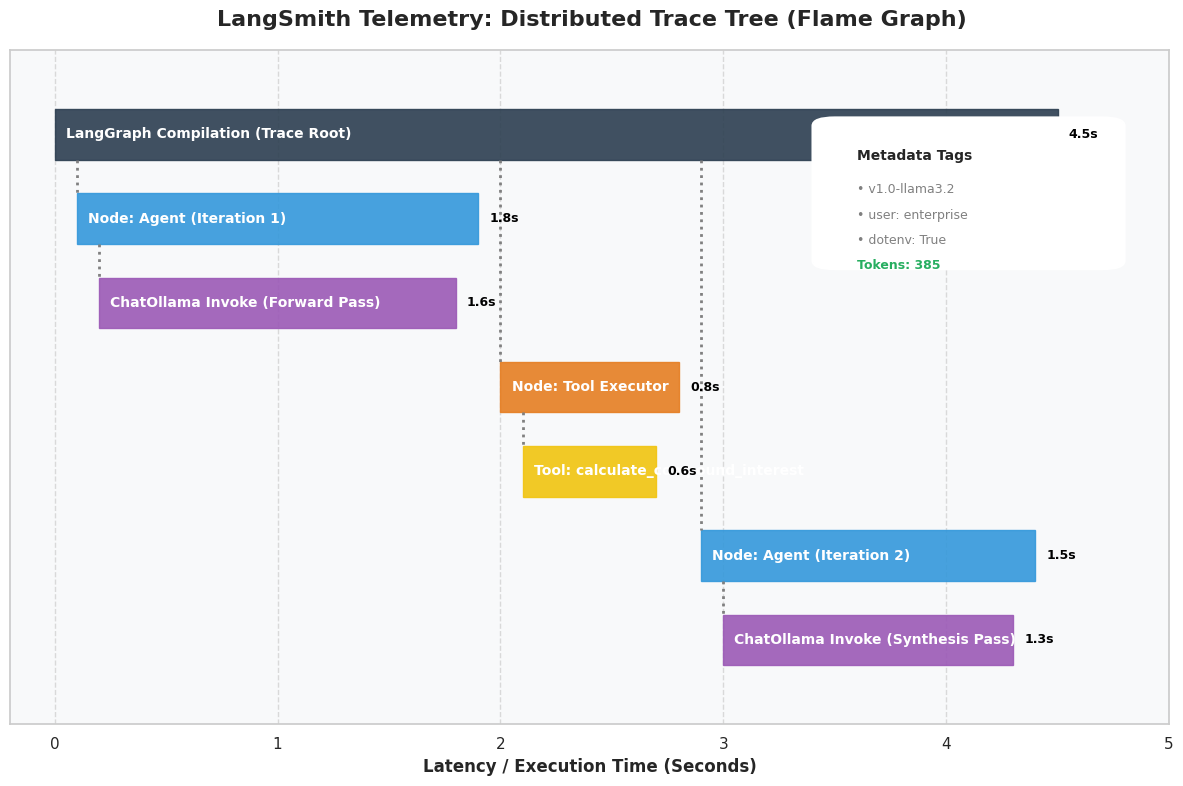

In [4]:
# Visualizing the LangSmith Trace Tree (Flame Graph Topology)
fig, ax = plt.subplots(figsize=(12, 8))
fig.suptitle("LangSmith Telemetry: Distributed Trace Tree (Flame Graph)", fontsize=16, fontweight='bold')

ax.set_facecolor('#f8f9fa')

# 1. Define the Trace Spans (Y-axis position, X-start, X-duration, Label, Color)
# Simulating the temporal physics of the execution we just ran
spans = [
    (9, 0.0, 4.5, "LangGraph Compilation (Trace Root)", "#2c3e50"),
    (8, 0.1, 1.8, "Node: Agent (Iteration 1)", "#3498db"),
    (7, 0.2, 1.6, "ChatOllama Invoke (Forward Pass)", "#9b59b6"),
    (6, 2.0, 0.8, "Node: Tool Executor", "#e67e22"),
    (5, 2.1, 0.6, "Tool: calculate_compound_interest", "#f1c40f"),
    (4, 2.9, 1.5, "Node: Agent (Iteration 2)", "#3498db"),
    (3, 3.0, 1.3, "ChatOllama Invoke (Synthesis Pass)", "#9b59b6")
]

# 2. Draw the Spans as Rectangles
for y, start, duration, label, color in spans:
    rect = patches.Rectangle((start, y - 0.3), duration, 0.6, fill=True, color=color, alpha=0.9, edgecolor='black', linewidth=1)
    ax.add_patch(rect)
    
    # Add Span Text
    ax.text(start + 0.05, y, label, color='white', fontweight='bold', va='center', fontsize=10)
    
    # Add Latency Text at the end of the bar
    ax.text(start + duration + 0.05, y, f"{duration}s", color='black', va='center', fontsize=9, fontweight='bold')

# 3. Draw Parent-Child Relationship Lines (The Rooted Tree)
# Root to Agent 1
ax.plot([0.1, 0.1], [8.7, 8.3], color='gray', linestyle=':', linewidth=2)
# Agent 1 to LLM Call
ax.plot([0.2, 0.2], [7.7, 7.3], color='gray', linestyle=':', linewidth=2)
# Root to Tool Node
ax.plot([2.0, 2.0], [8.7, 6.3], color='gray', linestyle=':', linewidth=2)
# Tool Node to Tool Call
ax.plot([2.1, 2.1], [5.7, 5.3], color='gray', linestyle=':', linewidth=2)
# Root to Agent 2
ax.plot([2.9, 2.9], [8.7, 4.3], color='gray', linestyle=':', linewidth=2)
# Agent 2 to LLM Call
ax.plot([3.0, 3.0], [3.7, 3.3], color='gray', linestyle=':', linewidth=2)

# 4. Format Axes
ax.set_xlim(-0.2, 5.0)
ax.set_ylim(2, 10)
ax.set_xlabel("Latency / Execution Time (Seconds)", fontsize=12, fontweight='bold')
ax.set_yticks([]) # Hide Y-axis numbers
ax.grid(axis='x', linestyle='--', alpha=0.7)

# Add Legend / Meta-Data Box
metadata_box = patches.FancyBboxPatch((3.5, 7.5), 1.2, 1.6, boxstyle="round,pad=0.1", fill=True, color='white', edgecolor='black', linewidth=1.5)
ax.add_patch(metadata_box)
ax.text(3.6, 8.7, "Metadata Tags", fontweight='bold', fontsize=10)
ax.text(3.6, 8.3, "• v1.0-llama3.2", fontsize=9, color='gray')
ax.text(3.6, 8.0, "• user: enterprise", fontsize=9, color='gray')
ax.text(3.6, 7.7, "• dotenv: True", fontsize=9, color='gray')
ax.text(3.6, 7.4, "Tokens: 385", fontweight='bold', fontsize=9, color='#27ae60')

plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of LangSmith Observability like **A Commercial Airplane's Flight Data Recorder vs. A Live Telemetry Control Room**:

* **Unobservable Pipeline (The Black Box)**: An airplane crashes (Your AI hallucinates an incorrect tool string). You have to send a team into the ocean to find the physical black box, extract the hard drive, and painstakingly parse raw `.log` files to figure out why the system failed at exactly 14:02. This takes weeks, and while you are debugging, your fleet is grounded.
* **LangSmith Telemetry (Mission Control)**: You are sitting in NASA Mission Control. Every single module on the spacecraft (The Nodes, The LLM, The Python Tools) is streaming real-time telemetry back to your dashboard asynchronously. If the oxygen pressure drops by $2\%$ in Sector 4 (A specific node execution spikes to 4.0 seconds latency), an alert triggers instantly. You can click into that exact micro-second, see the exact payload the LLM received, read the latency anomaly, and deploy a fix to the swarm before the user even realizes there was an issue.